# TFMA Analysis — Adult Census Income Pipeline
COMP315 — AI Software Test & ML/Ops

This notebook loads the TFMA evaluation artifact produced by the `Evaluator` component, renders slicing metrics, inspects fairness indicators, and compares runs. **Run the pipeline (via Airflow) at least once before running this notebook** so an eval result artifact exists under your pipeline root.

In [1]:
import sys
import tensorflow as tf

print("Python:", sys.version)
print("Python executable:", sys.executable)
print("TensorFlow version:", getattr(tf, "__version__", "NO VERSION"))
print("TensorFlow location:", getattr(tf, "__file__", "NO FILE"))
print("Has tf.Tensor:", hasattr(tf, "Tensor"))

d:\Anaconda\envs\tfx-env\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Python: 3.10.20 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:13:20) [MSC v.1942 64 bit (AMD64)]
Python executable: d:\Anaconda\envs\tfx-env\python.exe
TensorFlow version: 2.13.1
TensorFlow location: d:\Anaconda\envs\tfx-env\lib\site-packages\tensorflow\__init__.py
Has tf.Tensor: True


In [2]:
import sys
!{sys.executable} -m pip show tensorflow
!{sys.executable} -m pip show tensorflow-model-analysis

Name: tensorflow
Version: 2.13.1
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: d:\anaconda\envs\tfx-env\lib\site-packages
Requires: tensorflow-intel
Required-by: tensorflow-model-analysis, tensorflow-serving-api, tfx-bsl, witwidget
Name: tensorflow-model-analysis
Version: 0.45.0
Summary: A library for analyzing TensorFlow models
Home-page: https://www.tensorflow.org/tfx/model_analysis/get_started
Author: Google LLC
Author-email: tensorflow-extended-dev@googlegroups.com
License: Apache 2.0
Location: d:\anaconda\envs\tfx-env\lib\site-packages
Requires: absl-py, apache-beam, attrs, ipython, ipywidgets, numpy, pandas, pillow, protobuf, pyarrow, scipy, six, tensorflow, tensorflow-metadata, tfx-bsl
Required-by: 


In [3]:
import tensorflow_model_analysis as tfma
print('TFMA version:', tfma.version.VERSION)

Failed to import GCSFileSystem; loading of this filesystem will be skipped. Error details: cannot import name 'storage' from 'google.cloud' (unknown location)


TFMA version: 0.45.0


## Step 1: Load and render TFMA results

Point `EVAL_RESULT_PATH` at the `Evaluator` component's `evaluation` artifact URI for your run. You can find this in the ML Metadata SQLite DB, or by browsing `<PIPELINE_ROOT>/Evaluator/evaluation/<execution_id>/`.

In [4]:
# TODO: replace with your actual Evaluator output URI, e.g.
# EVAL_RESULT_PATH = (
#     '/home/<user>/COMP315/airflow_pipeline_outputs/'
#     'adult_census_tfx_output/Evaluator/evaluation/<execution_id>'
# )
EVAL_RESULT_PATH = r"C:\Users\three\tfma_evaluation\8"

eval_result = tfma.load_eval_result(EVAL_RESULT_PATH)

EVAL_RESULT_PATH_2 = r"C:\Users\three\tfma_evaluation\17"

eval_result_2 = tfma.load_eval_result(EVAL_RESULT_PATH_2)


tfma.view.render_slicing_metrics(eval_result)

Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`


Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`


SlicingMetricsViewer(config={'weightedExamplesColumn': 'example_count'}, data=[{'slice': 'Overall', 'metrics':…

**Written summary — overall + per-slice accuracy/AUC:**

_TODO: after running the cell above, fill in what you observe for the overall slice vs. the `sex_xf` and `race_xf` slices — e.g. which subgroup has the lowest accuracy/AUC, and by how much._

## Step 2: Inspect fairness metrics

Renders the Fairness Indicators dashboard for the same eval result, showing metric disparities between slices at chosen decision thresholds.

In [5]:
import pandas as pd

rows = []

for slice_data, metrics_data in eval_result.slicing_metrics:
    slice_name = "Overall"
    slice_value = "All"

    if slice_data:
        feature, value = slice_data[0]
        slice_name = feature
        slice_value = value

    metrics = metrics_data[""][""]

    rows.append({
        "Feature": slice_name,
        "Slice": slice_value,
        "Examples": metrics["example_count"]["doubleValue"],
        "Accuracy": metrics["accuracy"]["doubleValue"],
        "AUC": metrics["auc"]["doubleValue"],
        "Precision": metrics["precision"]["doubleValue"],
        "Recall": metrics["recall"]["doubleValue"],
        "Loss": metrics["loss"]["doubleValue"]
    })

fairness_df = pd.DataFrame(rows)

fairness_df

,Feature,Slice,Examples,Accuracy,AUC,Precision,Recall,Loss
0,sex_xf,0,7303.0,0.818842,0.893590,0.703463,0.718073,0.375920
1,Overall,All,10909.0,0.855074,0.916530,0.696834,0.709249,0.309697
2,race_xf,0,9316.0,0.848111,0.912625,0.697998,0.716443,0.323522
3,race_xf,1,1030.0,0.913592,0.949505,0.700935,0.568182,0.184871
4,sex_xf,1,3606.0,0.928453,0.942893,0.656000,0.656000,0.175580
5,race_xf,2,370.0,0.827027,0.891953,0.675439,0.740385,0.366665
6,race_xf,4,94.0,0.936170,0.954023,0.555556,0.714286,0.165897
7,race_xf,3,99.0,0.929293,0.883264,0.750000,0.545455,0.231060


In [6]:
tfma.view.render_slicing_metrics(eval_result)

SlicingMetricsViewer(config={'weightedExamplesColumn': 'example_count'}, data=[{'slice': 'Overall', 'metrics':…

In [7]:
from IPython.display import display
import tensorflow_model_analysis as tfma

display(
    tfma.view.render_slicing_metrics(
        eval_result,
        slicing_spec=tfma.SlicingSpec(
            feature_keys=['sex_xf']
        )
    )
)

SlicingMetricsViewer(config={'weightedExamplesColumn': 'example_count'}, data=[{'slice': 'sex_xf:0', 'metrics'…

In [8]:
from IPython.display import display
import tensorflow_model_analysis as tfma

display(
    tfma.view.render_slicing_metrics(
        eval_result,
        slicing_spec=tfma.SlicingSpec(
            feature_keys=['race_xf']
        )
    )
)

SlicingMetricsViewer(config={'weightedExamplesColumn': 'example_count'}, data=[{'slice': 'race_xf:0', 'metrics…

**Fairness analysis (required for the class deliverable):**

_TODO — answer explicitly:_
1. *Which slice has the lowest performance?*
2. *Why might that be? (e.g. class imbalance within the slice, under-representation in training data, correlated features)*
3. *What data collection or preprocessing step could close the gap?*

### Fairness Analysis

**1. Which slice has the lowest performance?**

The **`race_xf = 1` slice has the lowest recall**, with a recall of approximately **0.5682**. This means the model correctly identifies only about 56.8% of the positive cases in this slice. In comparison, other race slices have higher recall, such as `race_xf = 2` with approximately **0.7404**.

Although `race_xf = 1` has relatively high overall accuracy (**0.9136**) and AUC (**0.9495**), its lower recall indicates that the model is missing a larger proportion of positive cases for this group.

**2. Why might that be?**

One possible explanation is **class imbalance within the slice**. If `race_xf = 1` contains relatively few positive examples, the model may not have enough representative training examples to learn the characteristics of positive cases for that group.

Another possibility is **under-representation in the training data**. The evaluation results show that `race_xf = 1` contains only **1,030 evaluation examples**, compared with **9,316** for `race_xf = 0`. This difference in representation may contribute to less reliable predictions for the smaller group.

Additionally, other features used by the model may be correlated with race and could cause the model to perform differently across groups.

**3. What data collection or preprocessing step could close the gap?**

A useful approach would be to **collect more representative training data for the under-represented race group**, particularly additional positive examples. The training dataset could also be balanced using techniques such as **stratified sampling or appropriate class/group weighting**.

Before retraining, the data should be checked to determine whether the `race_xf = 1` group has substantially fewer positive examples than the other groups. Increasing representation and ensuring that each group has sufficient examples from both classes could help the model learn more consistent patterns and reduce the recall disparity.

Overall, the TFMA results indicate a potential fairness concern because the model's recall varies substantially across race slices. Further investigation of the training-data distribution would be necessary before concluding that race itself is the direct cause of the performance difference.


## Step 3: Compare two runs

Run the pipeline a second time after changing something (e.g. a hyperparameter in `adult_trainer_module.py`, or `TRAIN_NUM_STEPS` in `adult_pipeline_airflow.py`). Load both eval results and compare.

In [9]:
from IPython.display import display
import tensorflow_model_analysis as tfma

print("===== RUN 1 =====")
display(tfma.view.render_slicing_metrics(eval_result))

print("===== RUN 2 =====")
display(tfma.view.render_slicing_metrics(eval_result_2))

===== RUN 1 =====


SlicingMetricsViewer(config={'weightedExamplesColumn': 'example_count'}, data=[{'slice': 'Overall', 'metrics':…

===== RUN 2 =====


SlicingMetricsViewer(config={'weightedExamplesColumn': 'example_count'}, data=[{'slice': 'Overall', 'metrics':…

**Run comparison summary:**

_TODO — state what you changed between runs, and whether it improved or degraded accuracy/AUC overall and on each slice._

## What-If Tool

Explore individual predictions and counterfactuals using the served model. Requires the `witwidget` package and a running model server (or a local `SavedModel` loaded via `WitConfigBuilder`'s `set_custom_predict_fn`).

In [10]:
from witwidget.notebook.visualization import WitWidget, WitConfigBuilder

print("WIT imported successfully")

WIT imported successfully


In [11]:
from witwidget.notebook.visualization import WitWidget, WitConfigBuilder

# TODO: load a sample of examples (e.g. a few hundred rows from your
# eval split) and wire up WitConfigBuilder to your pushed SavedModel,
# then: WitWidget(config_builder, height=800)

In [12]:
import tensorflow as tf

MODEL_PATH = r"C:\Users\three\wit_model"

model = tf.saved_model.load(MODEL_PATH)

print("Signatures:")
print(list(model.signatures.keys()))

print("\nServing signature:")
print(model.signatures["serving_default"])

Signatures:
['serving_default', 'transform_features']

Serving signature:
ConcreteFunction signature_wrapper(*, examples)
  Args:
    examples: string Tensor, shape=(None,)
  Returns:
    {'outputs': <1>}
      <1>: float32 Tensor, shape=(None, 1)


In [13]:
import pandas as pd

CSV_PATH = r"C:\Users\three\adult.csv"

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 3 rows:")
display(df.head(3))

Shape: (32561, 16)

Columns:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'Unnamed: 5', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'target']

First 3 rows:


,age,workclass,fnlwgt,education,education-num,Unnamed: 5,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,39,State-gov,77516,Bachelors,13,NaN,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,NaN,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,NaN,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K


d:\Anaconda\envs\tfx-env\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Sample shape: (300, 15)
Columns: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'target']
Number of WIT examples: 300
First example:
{'age': '27', 'workclass': 'Private', 'fnlwgt': '160178', 'education': 'Some-college', 'education-num': '10', 'marital-status': 'Divorced', 'occupation': 'Adm-clerical', 'relationship': 'Not-in-family', 'race': 'White', 'sex': 'Female', 'capital-gain': '0', 'capital-loss': '0', 'hours-per-week': '38', 'native-country': 'United-States', 'target': '<=50K'}

Model loaded successfully.
Signatures: ['serving_default', 'transform_features']

Serving signature:
ConcreteFunction signature_wrapper(*, examples)
  Args:
    examples: string Tensor, shape=(None,)
  Returns:
    {'outputs': <1>}
      <1>: float32 Tensor, shape=(None, 1)

Test predictions:
[{'<=50K': 0.9941270356066525, '>50K': 0.005872964393347502}, {'<=50K'

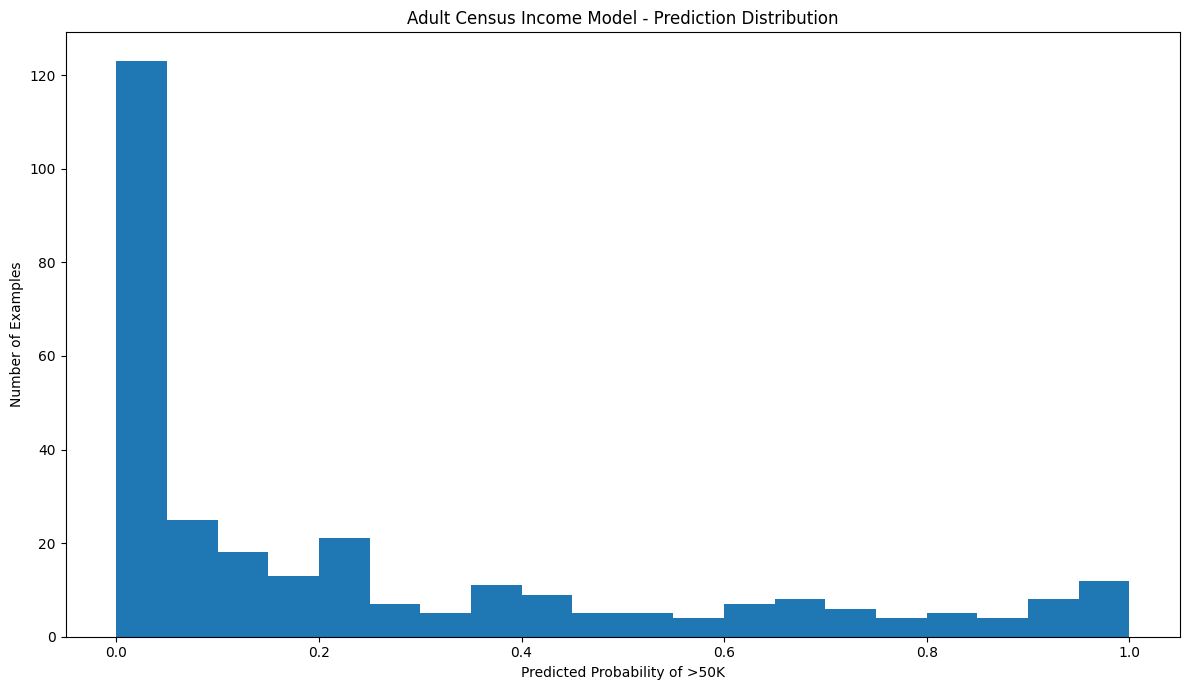


Visualization saved to: adult_census_prediction_visualization.png


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf

from witwidget.notebook.visualization import WitWidget, WitConfigBuilder


# =========================================================
# 1. Load the Adult Census dataset
# =========================================================

DATA_PATH = r"C:\Users\three\adult.csv"
MODEL_PATH = r"C:\Users\three\wit_model"

df = pd.read_csv(DATA_PATH)

# Remove accidental CSV column if present
if "Unnamed: 5" in df.columns:
    df = df.drop(columns=["Unnamed: 5"])

# Clean whitespace from string columns
for column in df.select_dtypes(include=["object"]).columns:
    df[column] = df[column].astype(str).str.strip()


# =========================================================
# 2. Take 300 examples
# =========================================================

sample_df = df.sample(
    n=min(300, len(df)),
    random_state=42
).copy()

print("Sample shape:", sample_df.shape)
print("Columns:", list(sample_df.columns))


# =========================================================
# 3. Convert rows to dictionaries
# =========================================================

examples = []

for _, row in sample_df.iterrows():

    example = {}

    for column in sample_df.columns:

        value = row[column]

        if pd.isna(value):
            value = ""

        elif isinstance(value, np.integer):
            value = int(value)

        elif isinstance(value, np.floating):
            value = float(value)

        else:
            value = str(value)

        example[column] = value

    examples.append(example)


print("Number of WIT examples:", len(examples))
print("First example:")
print(examples[0])


# =========================================================
# 4. Load the SavedModel
# =========================================================

model = tf.saved_model.load(MODEL_PATH)

print("\nModel loaded successfully.")
print("Signatures:", list(model.signatures.keys()))

serving_fn = model.signatures["serving_default"]

print("\nServing signature:")
print(serving_fn)


# =========================================================
# 5. Convert a WIT example into tf.Example
# =========================================================

FEATURE_COLUMNS = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country"
]


def make_tf_example(example):

    feature = {}

    for column in FEATURE_COLUMNS:

        value = example[column]

        # Numeric columns
        if column in [
            "age",
            "fnlwgt",
            "education-num",
            "capital-gain",
            "capital-loss",
            "hours-per-week"
        ]:
            feature[column] = tf.train.Feature(
                int64_list=tf.train.Int64List(
                    value=[int(float(value))]
                )
            )

        # Categorical/string columns
        else:
            feature[column] = tf.train.Feature(
                bytes_list=tf.train.BytesList(
                    value=[str(value).encode("utf-8")]
                )
            )

    tf_example = tf.train.Example(
        features=tf.train.Features(feature=feature)
    )

    return tf_example.SerializeToString()


# =========================================================
# 6. Prediction function for WIT
# =========================================================

def predict(examples):

    serialized_examples = [
        make_tf_example(example)
        for example in examples
    ]

    input_tensor = tf.constant(
        serialized_examples,
        dtype=tf.string
    )

    predictions = serving_fn(
        examples=input_tensor
    )["outputs"]

    predictions = predictions.numpy().flatten()

    # WIT expects a list of dictionaries for classification.
    # The keys are the class labels.
    results = []

    for probability in predictions:
        results.append({
            "<=50K": float(1.0 - probability),
            ">50K": float(probability)
        })

    return results


# =========================================================
# 7. Test prediction function BEFORE launching WIT
# =========================================================

test_predictions = predict(examples[:5])

print("\nTest predictions:")
print(test_predictions)

print("\nNumber of predictions:")
print(len(test_predictions))


# =========================================================
# 8. Create WIT configuration
# =========================================================

config_builder = WitConfigBuilder(
    examples
)

config_builder.set_model_type("classification")
config_builder.set_model_name("Adult Census Income Model")
config_builder.set_label_vocab(["<=50K", ">50K"])
config_builder.set_custom_predict_fn(predict)


# =========================================================
# 9. Save WIT-style prediction visualization as PNG
# =========================================================

import matplotlib.pyplot as plt

# Generate predictions for all 300 examples
all_predictions = predict(examples)

# Get probability of >50K
probabilities = [
    prediction[">50K"]
    for prediction in all_predictions
]

# Create a visualization
plt.figure(figsize=(12, 7))

plt.hist(
    probabilities,
    bins=20
)

plt.xlabel("Predicted Probability of >50K")
plt.ylabel("Number of Examples")
plt.title("Adult Census Income Model - Prediction Distribution")

plt.tight_layout()

# Save PNG in the same folder as the notebook/script
OUTPUT_PATH = "adult_census_prediction_visualization.png"

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\nVisualization saved to: {OUTPUT_PATH}")

**What-If Tool findings (attach screenshots in your report, not here):**

_TODO — for at least 3 counterfactual examples and 1 fairness threshold analysis, write a paragraph each: what did the model appear to have learned, and were there surprising or concerning patterns?_